In [2]:
!pip install --upgrade numpy scipy scikit-learn threadpoolctl

In [4]:
pip install "numpy<2" --force-reinstall

  Obtaining dependency information for numpy<2 from https://files.pythonhosted.org/packages/1a/2e/151484f49fd03944c4a3ad9c418ed193cfd02724e138ac8a9505d056c582/numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the ke

Loading and preprocessing data...
Extracting EDF parameters from /Users/asmitdesai/Desktop/ml-project-sectionb-12/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)

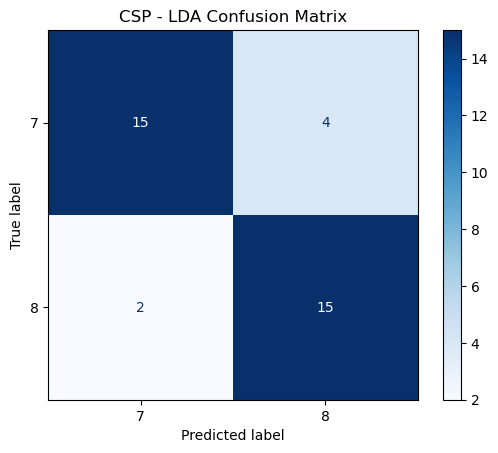

Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
  Accuracy for SVM: 80.56%


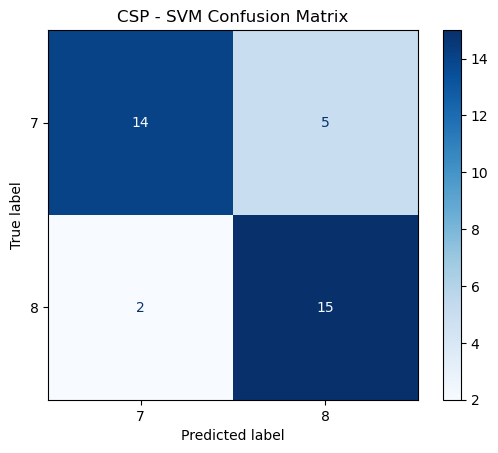

Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.2e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
  Accuracy for k-NN: 75.00%


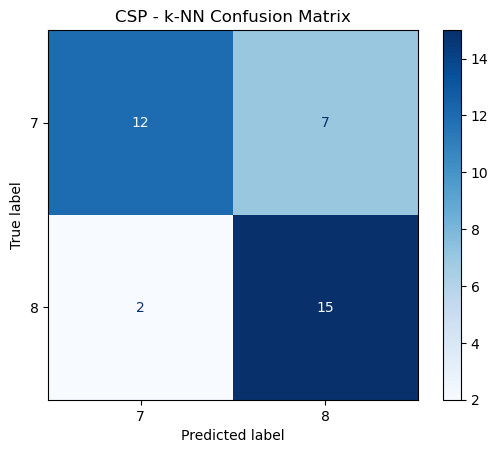


RESULTS FOR BAND POWER FEATURES:
  Accuracy for LDA: 58.33%


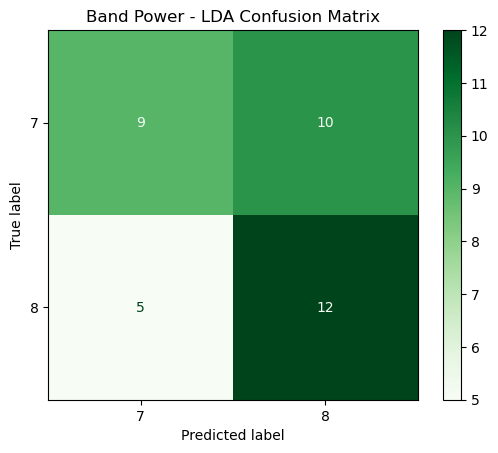

  Accuracy for SVM: 55.56%


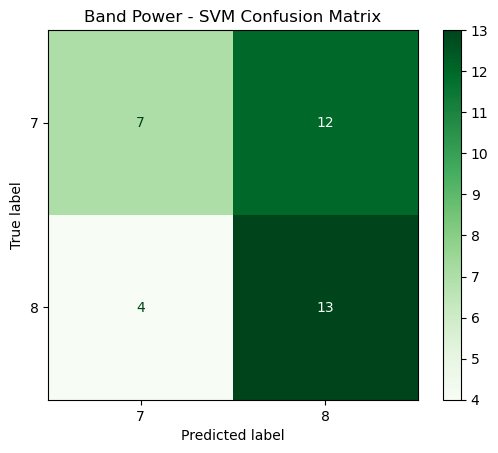

  Accuracy for k-NN: 61.11%


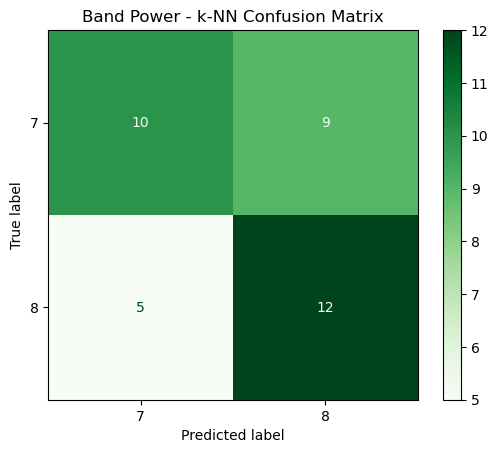

In [2]:
import mne
from mne.io import read_raw_gdf
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("Loading and preprocessing data...")
raw = read_raw_gdf('A01T.gdf', preload=True)
raw.set_montage('standard_1020', on_missing='warn')
raw.pick_types(eeg=True, exclude=['EOG'])
raw.filter(l_freq=8., h_freq=30., fir_design='firwin')

events, event_id_dict = mne.events_from_annotations(raw)
event_codes = {'left_hand': event_id_dict['769'], 'right_hand': event_id_dict['770']}

epochs = mne.Epochs(raw, events, event_id=event_codes, tmin=0.5, tmax=3.5, preload=True, baseline=None)
labels = epochs.events[:, -1]

le = LabelEncoder()
y = le.fit_transform(labels)
print("Preprocessing complete.")

print("\nExtracting Features...")
X_csp = epochs.get_data()
print(f"Shape of data for CSP: {X_csp.shape}")
psds, freqs = epochs.compute_psd(method='welch', fmin=8., fmax=30., n_fft=256).get_data(return_freqs=True)
X_bandpower = np.mean(psds, axis=2).reshape(len(psds), -1)
print(f"Shape of band power features: {X_bandpower.shape}")

print("\n--- Training and Evaluating All Models ---")
classifiers = {
    "LDA": LDA(),
    "SVM": SVC(),
    "k-NN": KNeighborsClassifier(n_neighbors=5)
}

# Test models using CSP features
print("\nRESULTS FOR CSP FEATURES:")
X_train, X_test, y_train, y_test = train_test_split(X_csp, y, test_size=0.25, random_state=42)
for name, classifier in classifiers.items():
    pipeline = Pipeline([
        ('CSP', CSP(n_components=6, reg=None, log=True)),
        (name, classifier)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"  Accuracy for {name}: {accuracy * 100:.2f}%")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"CSP - {name} Confusion Matrix")
    plt.show()

# Test models using Band Power features
print("\nRESULTS FOR BAND POWER FEATURES:")
X_train, X_test, y_train, y_test = train_test_split(X_bandpower, y, test_size=0.25, random_state=42)
for name, classifier in classifiers.items():
    pipeline = Pipeline([
        ('Scaler', StandardScaler()),
        (name, classifier)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"  Accuracy for {name}: {accuracy * 100:.2f}%")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Greens')
    plt.title(f"Band Power - {name} Confusion Matrix")
    plt.show()
